# library

In [19]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# load data

In [20]:
# =========================================================
# 2. LOAD DATASET
# =========================================================

data = pd.read_csv(r"D:\Sem 4\PBL\data\raw\Retail-Supply-Chain-Sales.csv")

print(data.shape)

data.head()

(9994, 23)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.96,2,0.00,41.91
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.94,3,0.00,219.58
2,3,CA-2016-138688,12/6/2016,12/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.62,2,0.00,6.87
3,4,US-2015-108966,11/10/2015,11/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.58,5,0.45,-383.03
4,5,US-2015-108966,11/10/2015,11/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.37,2,0.20,2.52


# Cek Informasi Data

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Row ID               9994 non-null   int64  
 1   Order ID             9994 non-null   object 
 2   Order Date           9994 non-null   object 
 3   Ship Date            9994 non-null   object 
 4   Ship Mode            9994 non-null   object 
 5   Customer ID          9994 non-null   object 
 6   Customer Name        9994 non-null   object 
 7   Segment              9994 non-null   object 
 8   Country              9994 non-null   object 
 9   City                 9994 non-null   object 
 10  State                9994 non-null   object 
 11  Postal Code          9994 non-null   int64  
 12  Region               9994 non-null   object 
 13  Retail Sales People  9994 non-null   object 
 14  Product ID           9994 non-null   object 
 15  Category             9994 non-null   o

# Cek Missing Value

In [22]:
data.isnull().sum()

Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Postal Code            0
Region                 0
Retail Sales People    0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Returned               0
Sales                  0
Quantity               0
Discount               0
Profit                 0
dtype: int64

# Cek Data Duplicate

In [23]:
print("Jumlah duplikasi :", data.duplicated().sum())

Jumlah duplikasi : 0


# Konversi Date --> datetime

In [24]:
data["Order Date"] = pd.to_datetime(
    data["Order Date"]
)

In [25]:
data["Ship Date"] = pd.to_datetime(
    data["Ship Date"]
)

# Mengurutkan Tanggal per Sub Kategori Produk

In [26]:
data = data.sort_values(
    ["Sub-Category", "Order Date"]
)

In [27]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
540,541,CA-2014-140795,2014-01-02,2014-03-02,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,...,Kelly Williams,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,Not,468.90,6,0.0,206.32
8242,8243,CA-2014-109855,2014-01-09,2014-05-09,Standard Class,LH-16900,Lena Hernandez,Consumer,United States,New York City,...,Chuck Magee,TEC-AC-10002842,Technology,Accessories,WD My Passport Ultra 2TB Portable External Har...,Not,357.00,3,0.0,57.12
765,766,CA-2014-162775,2014-01-13,2014-01-15,Second Class,CS-12250,Chris Selesnick,Corporate,United States,Bossier City,...,Cassandra Brandow,TEC-AC-10003174,Technology,Accessories,Plantronics S12 Corded Telephone Headset System,Not,646.74,6,0.0,258.70
1913,1914,CA-2014-103366,2014-01-15,2014-01-17,First Class,EH-13990,Erica Hackney,Consumer,United States,Roswell,...,Cassandra Brandow,TEC-AC-10003628,Technology,Accessories,Logitech 910-002974 M325 Wireless Mouse for We...,Not,149.95,5,0.0,65.98
9946,9947,CA-2014-111157,2014-02-03,2014-06-03,Standard Class,NH-18610,Nicole Hansen,Corporate,United States,Philadelphia,...,Chuck Magee,TEC-AC-10004353,Technology,Accessories,Hypercom P1300 Pinpad,Not,151.20,3,0.2,32.13


# Cek Sub Kategori Produk

In [28]:
subcategories = (
    data["Sub-Category"]
    .unique()
)

print("total produk sub kategori :",len(subcategories))

print("\n", subcategories)

total produk sub kategori : 17

 ['Accessories' 'Appliances' 'Art' 'Binders' 'Bookcases' 'Chairs' 'Copiers'
 'Envelopes' 'Fasteners' 'Furnishings' 'Labels' 'Machines' 'Paper'
 'Phones' 'Storage' 'Supplies' 'Tables']


In [29]:
# Urutan produk mulai dari terlaris hingga terseret
top_products = (
    data.groupby('Sub-Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

top_products

Sub-Category
Binders        5974
Paper          5178
Furnishings    3563
Phones         3289
Storage        3158
Art            3000
Accessories    2976
Chairs         2356
Appliances     1729
Labels         1400
Tables         1241
Fasteners       914
Envelopes       906
Bookcases       868
Supplies        647
Machines        440
Copiers         234
Name: Quantity, dtype: int64

# Cek Jumlah Data Per Produk

In [30]:
product_summary = (

    data.groupby("Sub-Category")
    .agg(
        total_rows=("Quantity", "count"),
        total_sales=("Quantity", "sum")
    )
    .sort_values(
        "total_rows",
        ascending=True
    )

)

print(product_summary.head(20))

              total_rows  total_sales
Sub-Category                         
Copiers               68          234
Machines             115          440
Supplies             190          647
Fasteners            217          914
Bookcases            228          868
Envelopes            254          906
Tables               319         1241
Labels               364         1400
Appliances           466         1729
Chairs               617         2356
Accessories          775         2976
Art                  796         3000
Storage              846         3158
Phones               889         3289
Furnishings          957         3563
Paper               1370         5178
Binders             1523         5974


# Tentukan Weekly atau Monthly

In [31]:
frequency_map = {}

In [32]:
for product in data["Sub-Category"].unique():

    temp = (

        data[
            data["Sub-Category"] == product
        ]
        .sort_values("Order Date")
        .copy()

    )

    temp["gap"] = (

        temp["Order Date"]
        .diff()
        .dt.days

    )

    mean_gap = temp["gap"].mean()

    if mean_gap <= 8:

        frequency_map[product] = "W"

    else:

        frequency_map[product] = "M"

In [33]:
frequency_map

{'Accessories': 'W',
 'Appliances': 'W',
 'Art': 'W',
 'Binders': 'W',
 'Bookcases': 'W',
 'Chairs': 'W',
 'Copiers': 'M',
 'Envelopes': 'W',
 'Fasteners': 'W',
 'Furnishings': 'W',
 'Labels': 'W',
 'Machines': 'M',
 'Paper': 'W',
 'Phones': 'W',
 'Storage': 'W',
 'Supplies': 'W',
 'Tables': 'W'}

# visualisasi pergerakan produk

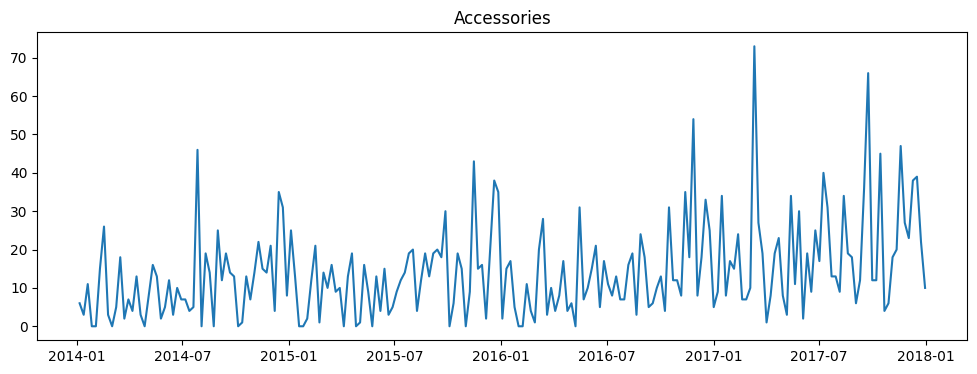

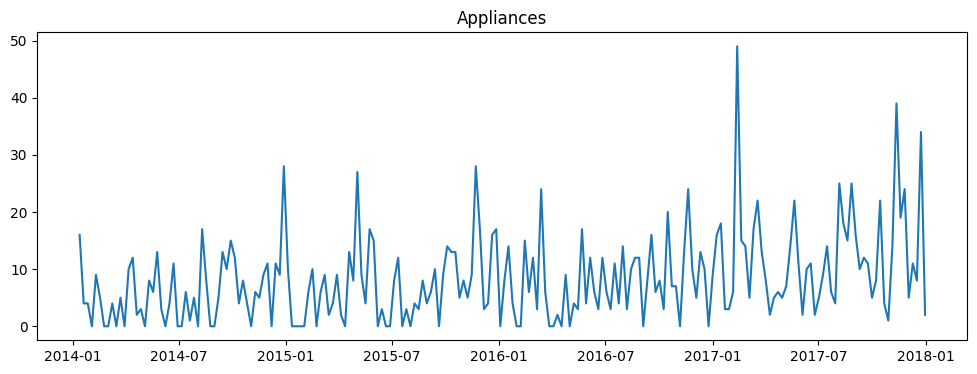

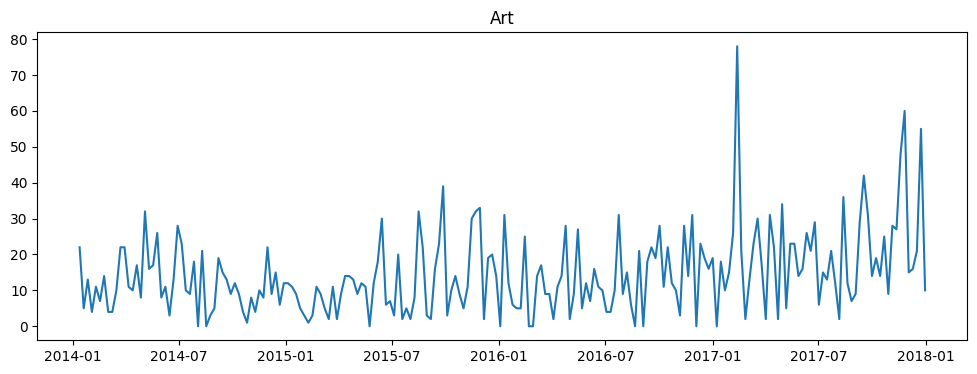

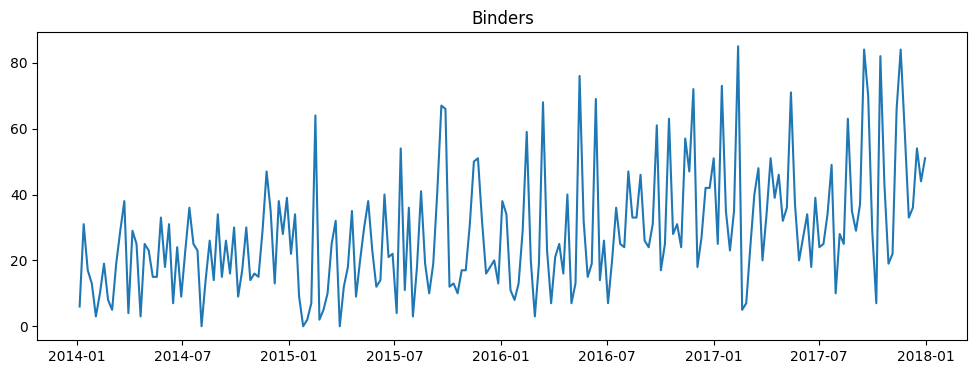

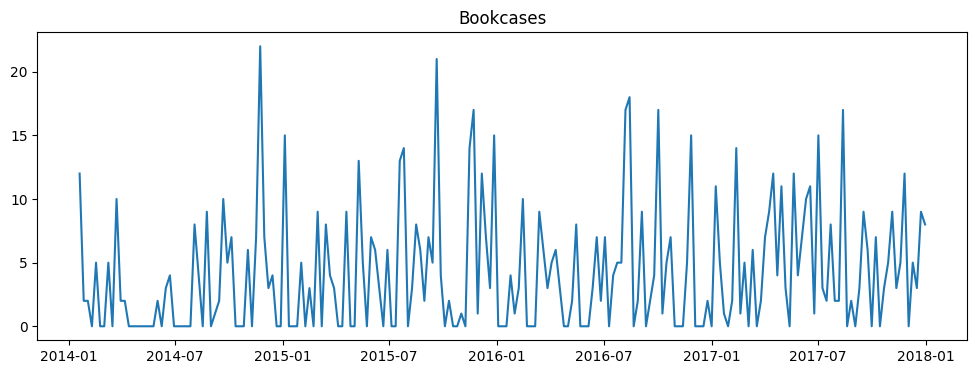

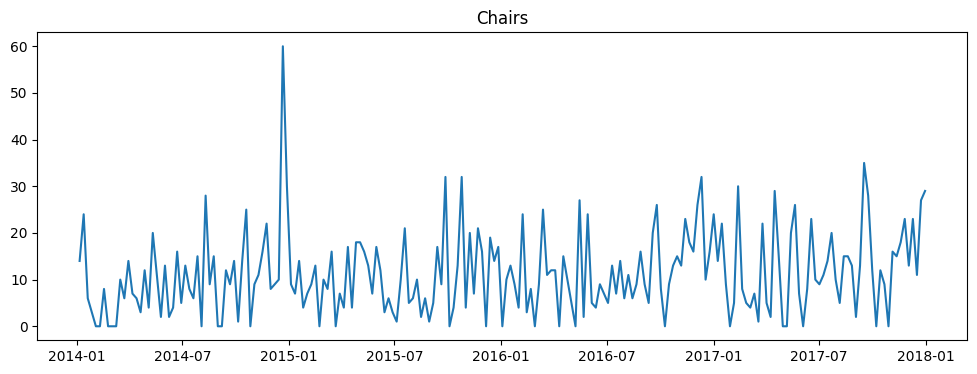

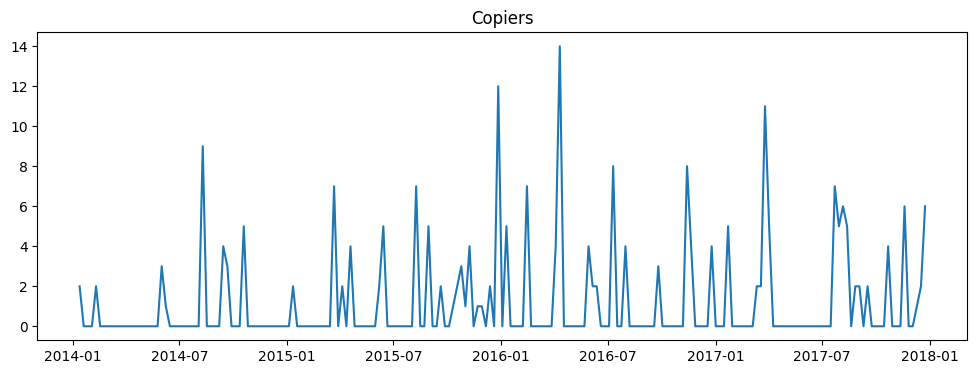

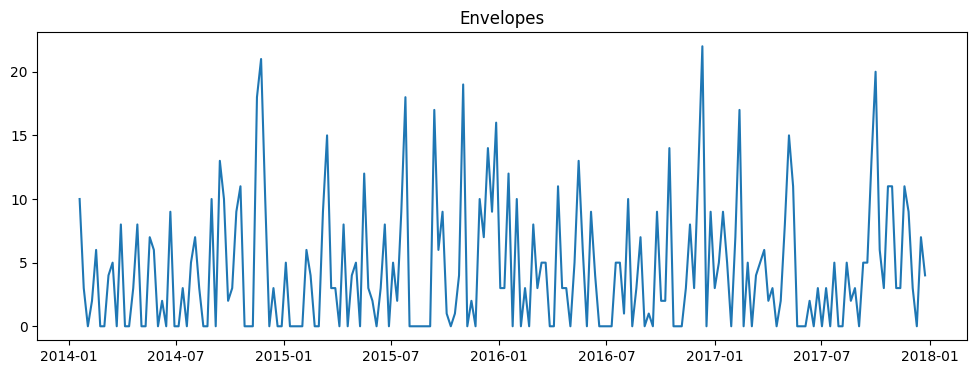

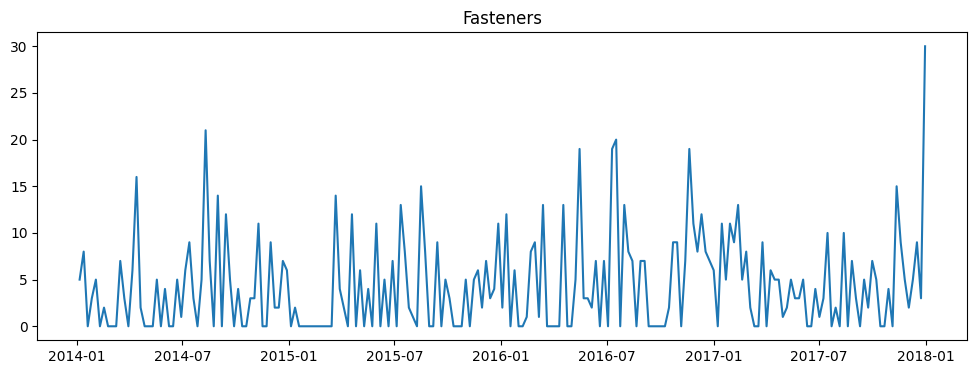

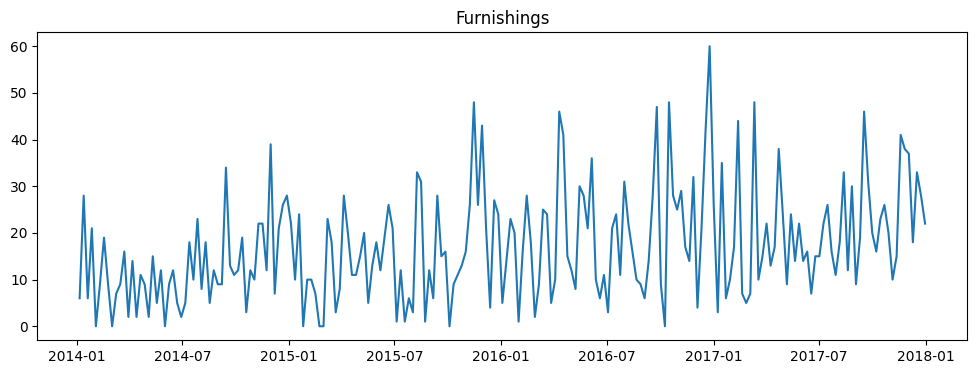

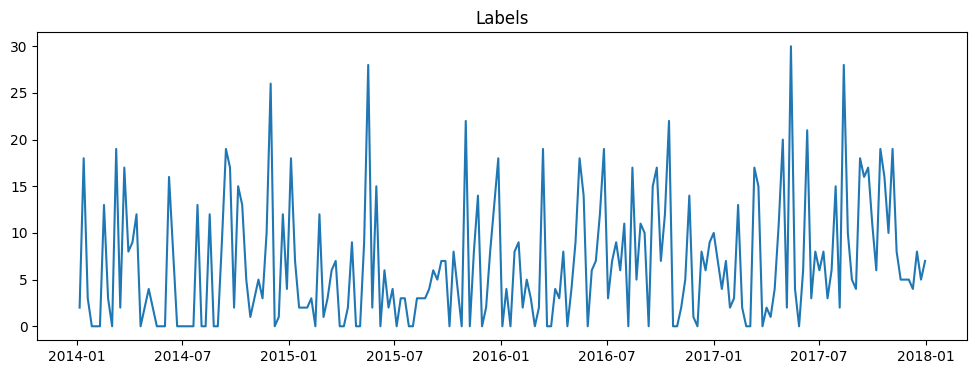

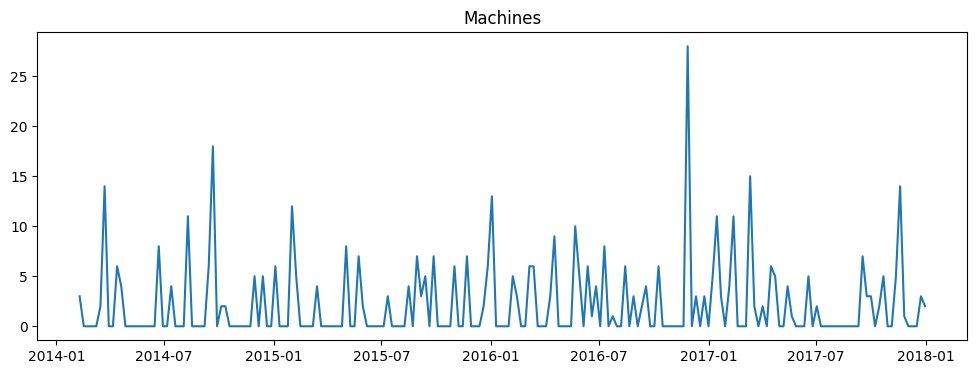

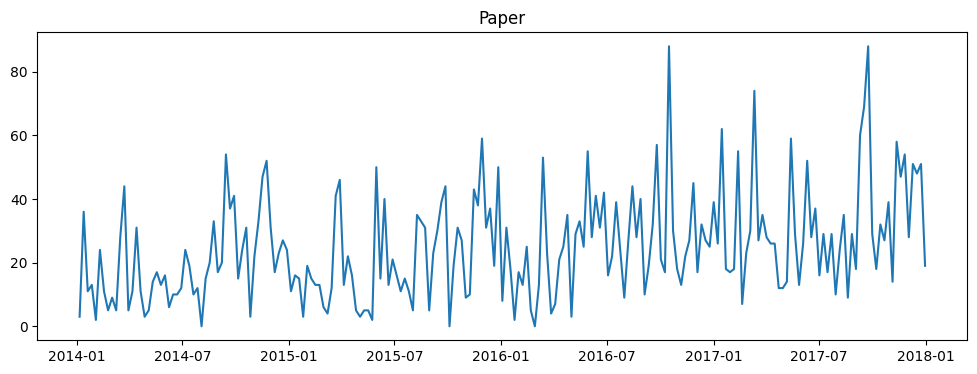

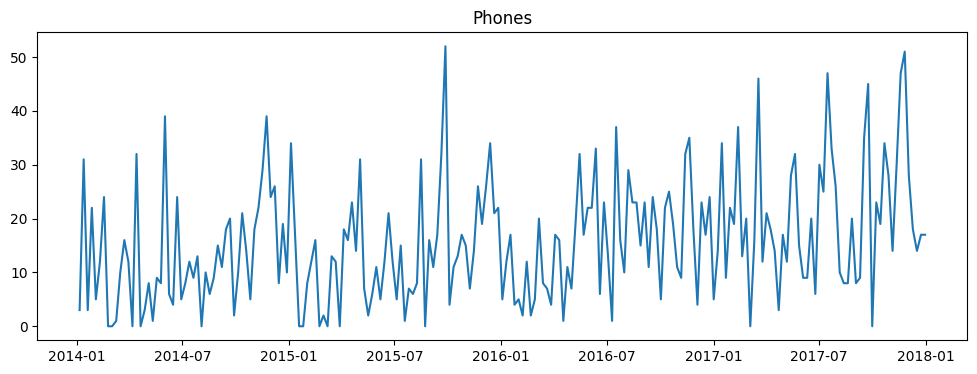

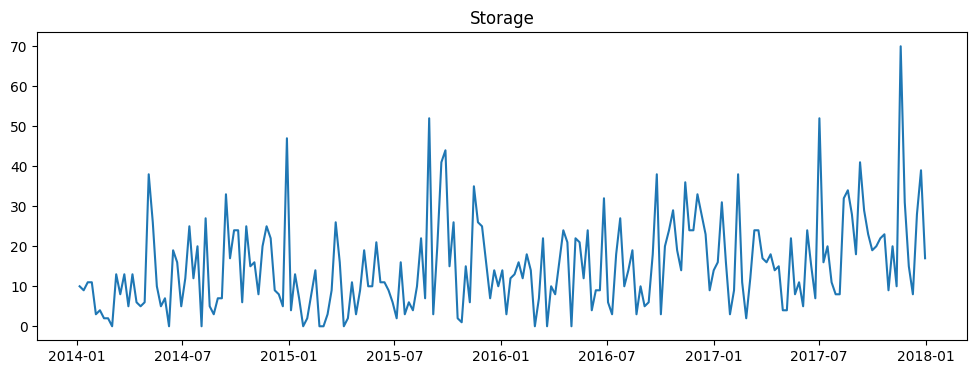

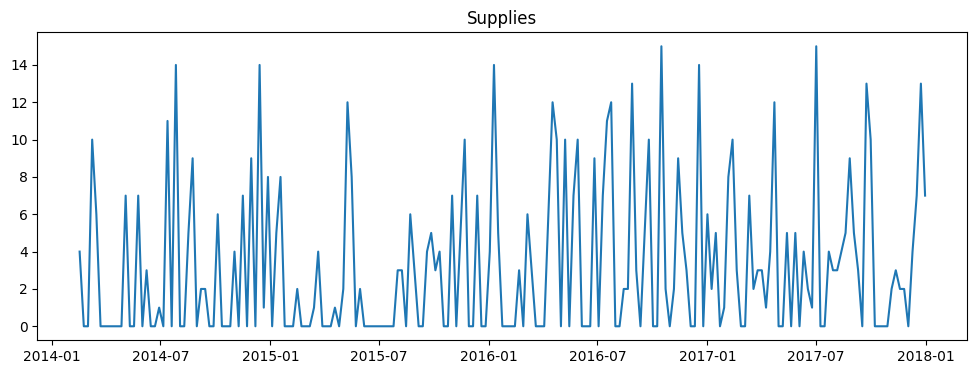

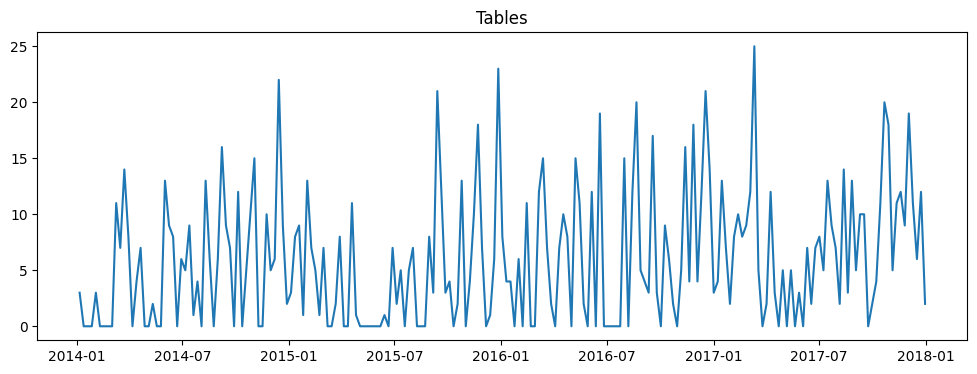

In [34]:
for product in data["Sub-Category"].unique():

    produk = data[
        data["Sub-Category"] == product
    ].copy()

    ts = (

        produk
        .set_index("Order Date")
        .resample("W")
        ["Quantity"]
        .sum()

    )

    plt.figure(figsize=(12,4))

    plt.plot(
        ts.index,
        ts.values
    )

    plt.title(product)

    plt.show()

In [35]:
# Filter hanya pesanan yang valid (tidak di-retur)
data_filtered = data[data['Returned'] == 'Not'].copy()

# =========================================================================
# 2. DEFINISIKAN RENTANG PREDIKSI (FREKUENSI) PER SUB-KATEGORI
# =========================================================================
# 'W' = Weekly (Mingguan) untuk produk fast-moving
# 'M' = Monthly (Bulanan) untuk produk slow-moving / high-value
frequency_mapping = {
'Accessories': 'W','Appliances': 'W','Art': 'W','Binders': 'W','Bookcases': 'W',
'Chairs': 'W','Copiers': 'M','Envelopes': 'W','Fasteners': 'W',
 'Furnishings': 'W','Labels': 'W','Machines': 'M','Paper': 'W','Phones': 'W',
 'Storage': 'W','Supplies': 'W','Tables': 'W'
}

# Tempat menyimpan hasil per kelompok frekuensi
weekly_chunks = []
monthly_chunks = []

# =========================================================================
# 3. LOOPING PREPROCESSING PER SUB-KATEGORI
# =========================================================================
unique_sub_cats = data_filtered['Sub-Category'].unique()

for sub_cat in unique_sub_cats:
    # Ambil data spesifik untuk 1 sub-kategori ini
    df_sub = data_filtered[data_filtered['Sub-Category'] == sub_cat].copy()
    
    # Ambil ketentuan frekuensi (Default ke 'W' jika tidak terdaftar di kamus)
    freq = frequency_mapping.get(sub_cat, 'W')
    
    # Urutkan berdasarkan tanggal sebelum resample
    df_sub = df_sub.sort_values('Order Date')
    
    # Set index ke Order Date untuk kebutuhan resampling waktu
    df_sub.set_index('Order Date', inplace=True)
    
    # Agregasi data berdasarkan frekuensi ('W' atau 'M')
    # Quantity, Sales, Profit dijumlahkan. Discount dirata-rata.
    df_resampled = df_sub.resample(freq).agg({
        'Quantity': 'sum',
        'Sales': 'sum',
        'Profit': 'sum',
        'Discount': 'mean'
    }).fillna(0) # Jika ada minggu/bulan yang kosong penjualan, isi dengan 0
    
    # ---------------------------------------------------------------------
    # FEATURE ENGINEERING (Pembuatan Fitur Lag & Eksternal Historis)
    # ---------------------------------------------------------------------
    # Lag Target Kuantitas
    df_resampled['Quantity_Lag_1'] = df_resampled['Quantity'].shift(1)
    df_resampled['Quantity_Lag_2'] = df_resampled['Quantity'].shift(2)
    
    # Rolling Mean dari Lag_1 untuk melihat tren jangka pendek (jendela 3 periode)
    df_resampled['Quantity_Rolling_Mean_3'] = df_resampled['Quantity_Lag_1'].rolling(window=3).mean()
    
    # Fitur Finansial Historis (Mencegah Data Leakage)
    # Kita gunakan Sales dan Profit periode lalu karena Sales periode ini belum ketahuan di masa depan
    df_resampled['Sales_Lag_1'] = df_resampled['Sales'].shift(1)
    df_resampled['Profit_Lag_1'] = df_resampled['Profit'].shift(1)
    
    # Fitur Finansial Aktif Hari Ini (Aman digunakan langsung karena diskon ditentukan di awal oleh toko)
    # Kolom 'Discount' tetap dipertahankan posisi aslinya
    
    # Fitur Kalender Eksternal
    df_resampled['Month'] = df_resampled.index.month
    df_resampled['Year'] = df_resampled.index.year
    if freq == 'W':
        df_resampled['Week_of_Year'] = df_resampled.index.isocalendar().week
        
    # Tambahkan kembali identitas nama sub-kategori
    df_resampled['Sub-Category'] = sub_cat
    
    # Hapus baris awal yang bernilai NaN akibat proses .shift() dan .rolling()
    df_resampled = df_resampled.dropna()
    
    # Masukkan ke dalam list master berdasarkan kelompok frekuensinya
    if freq == 'W':
        weekly_chunks.append(df_resampled)
    else:
        monthly_chunks.append(df_resampled)

# =========================================================================
# 4. GABUNGKAN MENJADI DATAFRAME MASTER SIAP PAKAI
# =========================================================================
df_weekly_master = pd.concat(weekly_chunks).reset_index() if weekly_chunks else pd.DataFrame()
df_monthly_master = pd.concat(monthly_chunks).reset_index() if monthly_chunks else pd.DataFrame()

print("--- PREPROCESSING SELESAI ---")
print(f"Master Data Mingguan (Weekly) : {df_weekly_master.shape[0]} baris, untuk {df_weekly_master['Sub-Category'].nunique()} Sub-Kategori")
print(f"Master Data Bulanan (Monthly) : {df_monthly_master.shape[0]} baris, untuk {df_monthly_master['Sub-Category'].nunique()} Sub-Kategori")

--- PREPROCESSING SELESAI ---
Master Data Mingguan (Weekly) : 3076 baris, untuk 15 Sub-Kategori
Master Data Bulanan (Monthly) : 89 baris, untuk 2 Sub-Kategori


In [36]:
df_weekly_master.head()

,Order Date,Quantity,Sales,Profit,Discount,Quantity_Lag_1,Quantity_Lag_2,Quantity_Rolling_Mean_3,Sales_Lag_1,Profit_Lag_1,Month,Year,Week_of_Year,Sub-Category
0,2014-01-26,0,0.00,0.00,0.00,11.0,3.0,6.666667,796.69,324.68,1,2014,4,Accessories
1,2014-02-02,0,0.00,0.00,0.00,0.0,11.0,4.666667,0.00,0.00,2,2014,5,Accessories
2,2014-02-09,15,888.32,190.43,0.15,0.0,0.0,3.666667,0.00,0.00,2,2014,6,Accessories
3,2014-02-16,24,1292.76,409.84,0.10,15.0,0.0,5.000000,888.32,190.43,2,2014,7,Accessories
4,2014-02-23,3,62.31,22.43,0.00,24.0,15.0,13.000000,1292.76,409.84,2,2014,8,Accessories


In [37]:
df_monthly_master.head()

,Order Date,Quantity,Sales,Profit,Discount,Quantity_Lag_1,Quantity_Lag_2,Quantity_Rolling_Mean_3,Sales_Lag_1,Profit_Lag_1,Month,Year,Sub-Category
0,2014-04-30,0,0.00,0.00,0.0,0.0,2.0,1.333333,0.00,0.0,4,2014,Copiers
1,2014-05-31,3,719.98,135.00,0.2,0.0,0.0,0.666667,0.00,0.0,5,2014,Copiers
2,2014-06-30,1,559.99,175.00,0.2,3.0,0.0,1.000000,719.98,135.0,6,2014,Copiers
3,2014-07-31,0,0.00,0.00,0.0,1.0,3.0,1.333333,559.99,175.0,7,2014,Copiers
4,2014-08-31,9,3549.94,949.99,0.2,0.0,1.0,1.333333,0.00,0.0,8,2014,Copiers


In [38]:
# =========================================================================
# 5. SIMPAN HASIL KE FILE CSV SEBAGAI BACKUP
# =========================================================================
df_weekly_master.to_csv('D:\Sem 4\PBL\data\processed\data_proses_mingguan.csv', index=False)
df_monthly_master.to_csv('D:\Sem 4\PBL\data\processed\data_proses_bulanan.csv', index=False)
print("File sukses disimpan ke komputer!")

File sukses disimpan ke komputer!
